# Phân tích và Tiền xử lý Dữ liệu Tàu Titanic

Trong notebook này, chúng ta sẽ thực hiện các bước tiền xử lý dữ liệu cần thiết cho bộ dữ liệu Titanic. Các bước này bao gồm làm sạch dữ liệu, kỹ thuật đặc trưng và chuyển đổi dữ liệu để chuẩn bị cho việc xây dựng mô hình học máy.

**Các bước chính:**
1.  **Làm sạch dữ liệu (Data Cleaning):** Xử lý các giá trị bị thiếu.
2.  **Kỹ thuật đặc trưng (Feature Engineering):** Tạo ra các đặc trưng mới từ dữ liệu hiện có.
3.  **Chuyển đổi dữ liệu (Data Transformation):** Mã hóa và chuẩn hóa các biến.

---
### Bắt đầu: Khai báo thư viện và tải dữ liệu

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tải dữ liệu từ các file CSV đã được bạn cung cấp
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# Để xử lý đồng bộ, ta sẽ kết hợp cả hai tập dữ liệu
# Giữ lại PassengerId của test_df để submit kết quả sau này
test_passenger_ids = test_df['PassengerId']
# Gộp hai tập dữ liệu
all_df = pd.concat([train_df.drop('Survived', axis=1), test_df], axis=0)

print("Kích thước dữ liệu huấn luyện:", train_df.shape)
print("Kích thước dữ liệu kiểm tra:", test_df.shape)
print("Kích thước dữ liệu tổng hợp:", all_df.shape)

all_df.head()

Kích thước dữ liệu huấn luyện: (891, 12)
Kích thước dữ liệu kiểm tra: (418, 11)
Kích thước dữ liệu tổng hợp: (1309, 11)


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Làm sạch dữ liệu (Data Cleaning)

Ở bước này, chúng ta sẽ xác định và xử lý các giá trị bị thiếu trong các cột quan trọng.

### 1.1. Phân tích giá trị bị thiếu (Missing Values)

Chúng ta sẽ kiểm tra xem mỗi cột có bao nhiêu giá trị bị thiếu và tỷ lệ của chúng.

          Số lượng thiếu  Phần trăm (%)
Cabin               1014      77.463713
Age                  263      20.091673
Embarked               2       0.152788
Fare                   1       0.076394


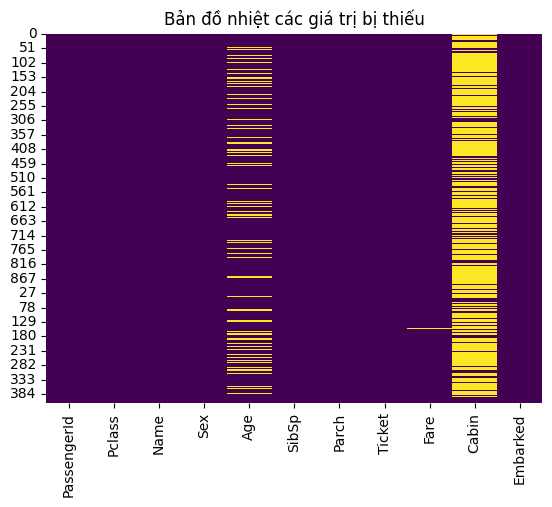

In [31]:
# Tính tổng số giá trị thiếu và phần trăm
missing_values = all_df.isnull().sum()
missing_percent = (missing_values / len(all_df)) * 100

missing_data = pd.DataFrame({
    'Số lượng thiếu': missing_values,
    'Phần trăm (%)': missing_percent
})

# Hiển thị các cột có giá trị thiếu, sắp xếp theo phần trăm giảm dần
print(missing_data[missing_data['Số lượng thiếu'] > 0].sort_values(by='Phần trăm (%)', ascending=False))

# Trực quan hóa
sns.heatmap(all_df.isnull(), cbar=False, cmap='viridis')
plt.title('Bản đồ nhiệt các giá trị bị thiếu')
plt.show()

### 1.2. Xử lý giá trị bị thiếu

Dựa trên phân tích trên, chúng ta sẽ xử lý các cột `Age`, `Cabin`, `Embarked` và `Fare`.

- **Embarked:** Có 2 giá trị thiếu. Ta sẽ điền bằng giá trị xuất hiện nhiều nhất (mode).
- **Fare:** Có 1 giá trị thiếu. Ta sẽ điền bằng giá trị trung vị (median).
- **Age:** Có khá nhiều giá trị thiếu. Ta sẽ điền bằng giá trị trung vị (median) để tránh ảnh hưởng của các giá trị ngoại lai.
- **Cabin:** Có quá nhiều giá trị thiếu (>77%). Việc điền giá trị sẽ không hiệu quả. Thay vào đó, ta sẽ tạo một đặc trưng mới là `HasCabin` để đánh dấu ai có thông tin cabin và ai không, sau đó xóa cột `Cabin` gốc.

In [32]:
# Tính toán các giá trị mode/median trước
embarked_mode = all_df['Embarked'].mode()[0]
fare_median = all_df['Fare'].median()
age_median = all_df['Age'].median()

print(f"Giá trị điền cho 'Embarked' (mode): '{embarked_mode}'")
print(f"Giá trị điền cho 'Fare' (median): {fare_median}")
print(f"Giá trị điền cho 'Age' (median): {age_median}")

# Gộp 3 thao tác fillna vào một lệnh duy nhất
all_df.fillna({
    'Embarked': embarked_mode,
    'Fare': fare_median,
    'Age': age_median
}, inplace=True)

print("\nĐã điền các giá trị thiếu cho Embarked, Fare, và Age.")

# Xử lý 'Cabin'
# Tạo đặc trưng mới 'HasCabin'
all_df['HasCabin'] = all_df['Cabin'].apply(lambda x: 0 if pd.isna(x) else 1)
# Xóa cột 'Cabin' gốc
all_df.drop('Cabin', axis=1, inplace=True)
print("Đã tạo cột 'HasCabin' và xóa cột 'Cabin'.")

# Kiểm tra lại các giá trị thiếu
print("\nSố lượng giá trị thiếu còn lại:")
print(all_df.isnull().sum())

Giá trị điền cho 'Embarked' (mode): 'S'
Giá trị điền cho 'Fare' (median): 14.4542
Giá trị điền cho 'Age' (median): 28.0

Đã điền các giá trị thiếu cho Embarked, Fare, và Age.
Đã tạo cột 'HasCabin' và xóa cột 'Cabin'.

Số lượng giá trị thiếu còn lại:
PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64


## 2. Kỹ thuật đặc trưng (Feature Engineering)

Từ các cột hiện có, chúng ta sẽ tạo ra các đặc trưng mới để giúp mô hình học tốt hơn.

### 2.1. Tạo đặc trưng: FamilySize và IsAlone

- **FamilySize:** Kích thước gia đình, bằng tổng của `SibSp` (anh chị em/vợ chồng) + `Parch` (cha mẹ/con cái) + 1 (bản thân hành khách).
- **IsAlone:** Một biến nhị phân cho biết hành khách đó có đi một mình hay không.

In [33]:
# Tạo FamilySize
all_df['FamilySize'] = all_df['SibSp'] + all_df['Parch'] + 1

# Tạo IsAlone
all_df['IsAlone'] = all_df['FamilySize'].apply(lambda x: 1 if x == 1 else 0)

print("Đã tạo các đặc trưng 'FamilySize' và 'IsAlone'.")
all_df[['FamilySize', 'IsAlone']].head()

Đã tạo các đặc trưng 'FamilySize' và 'IsAlone'.


,FamilySize,IsAlone
0,2,0
1,2,0
2,1,1
3,2,0
4,1,1


### 2.2. Tạo đặc trưng: Title

Chúng ta có thể trích xuất danh xưng (Mr, Mrs, Miss,...) từ cột `Name`. Điều này có thể cung cấp thông tin về giới tính, tuổi tác và tình trạng xã hội.

In [34]:
# Trích xuất danh xưng bằng biểu thức chính quy (regular expression)
all_df['Title'] = all_df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

# Xem các loại danh xưng và tần suất
print(all_df['Title'].value_counts())

# Nhóm các danh xưng hiếm vào một nhóm 'Rare'
rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'Mlle', 'Countess', 'Ms', 'Lady', 'Jonkheer', 'Dona', 'Mme', 'Capt', 'Sir']
all_df['Title'] = all_df['Title'].replace(rare_titles, 'Rare')

print("\nDanh xưng sau khi đã được nhóm lại:")
print(all_df['Title'].value_counts())

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Major         2
Mlle          2
Ms            2
Mme           1
Don           1
Sir           1
Lady          1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

Danh xưng sau khi đã được nhóm lại:
Title
Mr        757
Miss      260
Mrs       197
Master     61
Rare       33
Don         1
Name: count, dtype: int64


### 2.3. Nhóm các biến liên tục (Binning)

Việc nhóm các biến liên tục như `Age` và `Fare` thành các khoảng giá trị (bin) có thể giúp mô hình nắm bắt các mối quan hệ phi tuyến tính.

- **Age:** Chia tuổi thành các nhóm (trẻ em, thanh niên, người lớn, người cao tuổi).
- **Fare:** Chia giá vé thành các nhóm dựa trên phân vị (quantiles).

In [35]:
# Binning cho cột Age
# Sử dụng pd.cut để chia thành 5 khoảng
all_df['AgeBin'] = pd.cut(all_df['Age'], bins=5, labels=False)

# Binning cho cột Fare
# Sử dụng pd.qcut để chia thành 4 khoảng dựa trên phân vị
all_df['FareBin'] = pd.qcut(all_df['Fare'], q=4, labels=False)

print("Đã tạo các đặc trưng 'AgeBin' và 'FareBin'.")
all_df[['Age', 'AgeBin', 'Fare', 'FareBin']].head()

Đã tạo các đặc trưng 'AgeBin' và 'FareBin'.


,Age,AgeBin,Fare,FareBin
0,22.0,1,7.2500,0
1,38.0,2,71.2833,3
2,26.0,1,7.9250,1
3,35.0,2,53.1000,3
4,35.0,2,8.0500,1


## 3. Chuyển đổi dữ liệu (Data Transformation)

Bây giờ chúng ta sẽ chuyển đổi các biến phân loại thành dạng số để mô hình có thể hiểu được.

### 3.1. Mã hóa các biến phân loại (Categorical Encoding)

- **Sex:** Dùng Label Encoding (`Male`: 0, `Female`: 1).
- **Embarked, Title, AgeBin, FareBin:** Dùng One-Hot Encoding vì các giá trị không có thứ tự.

In [36]:
# Label Encoding cho 'Sex'
all_df['Sex'] = all_df['Sex'].map({'male': 0, 'female': 1}).astype(int)

# One-Hot Encoding cho các cột còn lại
categorical_cols = ['Embarked', 'Title', 'AgeBin', 'FareBin']
all_df = pd.get_dummies(all_df, columns=categorical_cols, prefix=categorical_cols)

print("Đã mã hóa các biến phân loại.")
all_df.head()

Đã mã hóa các biến phân loại.


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,HasCabin,...,Title_Rare,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3
0,1,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,...,False,False,True,False,False,False,True,False,False,False
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,1,...,False,False,False,True,False,False,False,False,False,True
2,3,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,...,False,False,True,False,False,False,False,True,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,1,...,False,False,False,True,False,False,False,False,False,True
4,5,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,...,False,False,False,True,False,False,False,True,False,False


### 3.2. Chuẩn hóa các biến số

Mặc dù trong kịch bản này chúng ta đã nhóm `Age` và `Fare` thành các biến phân loại, nếu muốn sử dụng chúng dưới dạng biến liên tục, việc chuẩn hóa là rất quan trọng để các thuật toán như SVM hay Logistic Regression hoạt động hiệu quả. Dưới đây là ví dụ về cách thực hiện (đoạn code này được chú thích vì chúng ta đã chọn phương pháp binning).

In [37]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# continuous_vars = ['Age', 'Fare', 'FamilySize']
# all_df[continuous_vars] = scaler.fit_transform(all_df[continuous_vars])

# print("Các biến liên tục đã được chuẩn hóa (ví dụ).")
# all_df[continuous_vars].head()

## 4. Hoàn thiện và Chuẩn bị dữ liệu cuối cùng

Cuối cùng, chúng ta sẽ xóa các cột không cần thiết hoặc đã được xử lý và tách dữ liệu trở lại thành hai tập train và test.

In [38]:
# Xóa các cột không cần thiết
cols_to_drop = ['Name', 'Ticket', 'PassengerId', 'SibSp', 'Parch', 'Age', 'Fare']
final_df = all_df.drop(columns=cols_to_drop)

# Tách lại thành tập train và test
# Thêm .copy() để tạo bản sao độc lập và tránh SettingWithCopyWarning
train_final = final_df.iloc[:len(train_df)].copy()
test_final = final_df.iloc[len(train_df):].copy() # Cũng nên thêm .copy() cho test_final

# Thêm lại cột 'Survived' cho tập train
# Bây giờ thao tác này an toàn vì train_final là một bản sao
train_final['Survived'] = train_df['Survived']

print("Kích thước tập train cuối cùng:", train_final.shape)
print("Kích thước tập test cuối cùng:", test_final.shape)

print("\n5 dòng đầu của tập train đã xử lý:")
display(train_final.head())

print("\n5 dòng đầu của tập test đã xử lý:")
display(test_final.head())

Kích thước tập train cuối cùng: (891, 24)
Kích thước tập test cuối cùng: (418, 23)

5 dòng đầu của tập train đã xử lý:


,Pclass,Sex,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Don,Title_Master,...,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3,Survived
0,3,0,0,2,0,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,0
1,1,1,1,2,0,True,False,False,False,False,...,False,False,True,False,False,False,False,False,True,1
2,3,1,0,1,1,False,False,True,False,False,...,False,True,False,False,False,False,True,False,False,1
3,1,1,1,2,0,False,False,True,False,False,...,False,False,True,False,False,False,False,False,True,1
4,3,0,0,1,1,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,0



5 dòng đầu của tập test đã xử lý:


,Pclass,Sex,HasCabin,FamilySize,IsAlone,Embarked_C,Embarked_Q,Embarked_S,Title_Don,Title_Master,...,Title_Rare,AgeBin_0,AgeBin_1,AgeBin_2,AgeBin_3,AgeBin_4,FareBin_0,FareBin_1,FareBin_2,FareBin_3
0,3,0,0,1,1,False,True,False,False,False,...,False,False,False,True,False,False,True,False,False,False
1,3,1,0,2,0,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2,2,0,0,1,1,False,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,3,0,0,1,1,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
4,3,1,0,3,0,False,False,True,False,False,...,False,False,True,False,False,False,False,True,False,False
